In [3]:
!pip install tensorflow

   ---------------------------------------- 0.0/390.3 MB ? eta -:--:--
   ---------------------------------------- 1.8/390.3 MB 9.1 MB/s eta 0:00:43
   ---------------------------------------- 3.1/390.3 MB 7.7 MB/s eta 0:00:51
   ---------------------------------------- 4.5/390.3 MB 7.3 MB/s eta 0:00:54
    --------------------------------------- 5.8/390.3 MB 7.0 MB/s eta 0:00:55
    --------------------------------------- 7.1/390.3 MB 6.7 MB/s eta 0:00:58
    --------------------------------------- 8.1/390.3 MB 6.6 MB/s eta 0:00:58
    --------------------------------------- 9.4/390.3 MB 6.4 MB/s eta 0:01:00
   - -------------------------------------- 11.3/390.3 MB 6.6 MB/s eta 0:00:58
   - -------------------------------------- 12.6/390.3 MB 6.6 MB/s eta 0:00:58
   - -------------------------------------- 13.9/390.3 MB 6.6 MB/s eta 0:00:57
   - -------------------------------------- 15.2/390.3 MB 6.5 MB/s eta 0:00:58
   - -------------------------------------- 16.8/390.3 MB 6.5 MB/s 


[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
pip show tensorflow

Name: tensorflow
Version: 2.18.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: A:\EDUCATIONAL\Data Science\Anaconda\Lib\site-packages
Requires: tensorflow-intel
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [7]:
pip install tensorflow-datasets

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ---------------------------------------- 0.0/5.3 MB ? eta -:--:--
   ------------- -------------------------- 1.8/5.3 MB 10.1 MB/s eta 0:00:01
   ------------------------- -------------- 3.4/5.3 MB 7.7 MB/s eta 0:00:01
   ----------------------------------- ---- 4.7/5.3 MB 7.3 MB/s eta 0:00:01
   ---------------------------------------- 5.3/5.3 MB 6.7 MB/s eta 0:00:00
  Created wheel for promise: filename=promise-2.3-py3-none-any.whl size=21544 sha256=ea2b78fad3627941d433a7d52fe6d8ce427105b67bcae6bea51db577205fe41f
  Stored in directory: c:\users\aiden\appdata\local\pip\cache\wheels\e7\e6\28\864bdfee5339dbd6ddcb5a186286a8e217648ec198bdf0097d
Successfully built promise
  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.20.3
    Uninstalling protobuf-3.20.3:
      Successfully uninstalled protobuf-3.20.3
Note: you may need to restart the kernel to use updated

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.32.0 requires protobuf<5,>=3.20, but you have protobuf 5.28.3 which is incompatible.

[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import tensorflow_datasets as tfds
print(tfds.__version__)


4.9.7


In [13]:
# Importing required libraries
import tensorflow as tf
from tensorflow.keras import layers, Sequential, models
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds
import numpy as np
from tensorflow.keras.layers import TextVectorization
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
import os

Problem Statement 1: 
Build a text classification RNN ( Recurrent Neural Network) model using IMDB dataset. 
Import the IMDB dataset using  tensorflow_datasets and perform the following tasks. 

Tasks to be performed:
•Import the required libraries
•Shuffle the data for training and create batches of text and label pairs
•Encode the text data
Note: The simplest way to process text for training is using the TextVectorization layer.
•Build a sequential model using tf.keras.Sequential function
•Compile the model
•Train the model using train dataset
•Test the data using tset dataset and evaluate the model by passing a sentence
Note: If the prediction is >= 0.0, it is positive else it is negative

Note: The simplest way to process text for training is using the TextVectorization layer.
Create the layer, and pass the dataset's text to the layer's .adapt method.
•Build a sequential model using tf.keras.Sequential function
•Compile the model
•Train the model using train dataset
•Test the data using tset dataset and evaluate the model by passing a sentence

Note: If the prediction is >= 0.0, it is positive else it is negative.

In [21]:
# Load the IMDB dataset
dataset, info = tfds.load('imdb_reviews', as_supervised=True, with_info=True)
train_data, test_data = dataset['train'], dataset['test']

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling C:\Users\aiden\tensorflow_datasets\imdb_reviews\plain_text\incomplete.7XNQ3Q_1.0.0\imdb_reviews-trai…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling C:\Users\aiden\tensorflow_datasets\imdb_reviews\plain_text\incomplete.7XNQ3Q_1.0.0\imdb_reviews-test…

Generating unsupervised examples...: 0 examples [00:00, ? examples/s]

Shuffling C:\Users\aiden\tensorflow_datasets\imdb_reviews\plain_text\incomplete.7XNQ3Q_1.0.0\imdb_reviews-unsu…

Dataset imdb_reviews downloaded and prepared to C:\Users\aiden\tensorflow_datasets\imdb_reviews\plain_text\1.0.0. Subsequent calls will reuse this data.


In [31]:
for example, label in train_data.take(3):
    print(f"Review: {example.numpy().decode('utf-8')}\nLabel: {label.numpy()}\n")

Review: This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it.
Label: 0

Review: I have been known to fall asleep during films, but this is usually due to a combination of things including, really tired, being warm and comfortable on the sette and having just eaten a lot. However on this occasion I fell asleep because the film was rubbish. The

In [35]:
# Shuffle and batch the data
BUFFER_SIZE = 10000
BATCH_SIZE = 64

train_data = train_data.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_data = test_data.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [37]:
# Preview a sample
for text, label in train_data.take(1):
    print(f"Sample text: {text.numpy()[0]}")
    print(f"Label: {label.numpy()[0]}")

Sample text: b"Adam Jones has a brilliant sense of humor. There is nothing i didn't like about this film. Cross Eyed was beautifully shot. Adam does a great job of, not only developing the main characters, but also the minor characters. <br /><br />Cross Eyed gives hope to every low budget film out there. That you don't have to spend a lot to create something worth watching. There is something to like for everyone. If you've had a terrible roommate. if you've ever picked on a dork in high school. if you've ever parked anywhere in the city. if you have any type of sense of humor at all you will love this film. This is the type of film that will be around for a long time and ends up resurfacing again once Adam makes a bigger name for himself. I look forward to Adam's future projects."
Label: 1


In [41]:
# Text Vectorization Layer
VOCAB_SIZE = 10000
SEQUENCE_LENGTH = 100

vectorize_layer = TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=SEQUENCE_LENGTH
)

# Adapt the vectorization layer to the training data
train_text = train_data.map(lambda x, y: x)
vectorize_layer.adapt(train_text)

In [43]:
# Define the RNN model
model = Sequential([
    vectorize_layer,
    Embedding(VOCAB_SIZE, 64),
    SimpleRNN(64, return_sequences=True),
    SimpleRNN(32),
    Dense(32, activation='relu'),
    Dense(1)
])

# Compile the model
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Train the model
history = model.fit(train_data, validation_data=test_data, epochs=3)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(test_data)
print(f"\nTest Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 63s 141ms/step - accuracy: 0.5074 - loss: 0.6967 - val_accuracy: 0.5000 - val_loss: 0.7037
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 48s 122ms/step - accuracy: 0.5545 - loss: 0.6593 - val_accuracy: 0.5137 - val_loss: 0.7243
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 52s 133ms/step - accuracy: 0.8057 - loss: 0.3915 - val_accuracy: 0.5259 - val_loss: 0.9598
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.5238 - loss: 0.9583

Test Loss: 0.9598188996315002
Test Accuracy: 0.525879979133606


In [45]:
# Test with a sample sentence
sample_text = tf.constant(["I can't say this is the worst movie ever made, but personally, I think it is that way."])
prediction = model.predict(sample_text)
print("\nSample Prediction:")
print("Text: ", sample_text.numpy()[0])
print("Prediction (>= 0.0 is positive, < 0.0 is negative): ", prediction[0][0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 880ms/step

Sample Prediction:
Text:  b"I can't say this is the worst movie ever made, but personally, I think it is that way."
Prediction (>= 0.0 is positive, < 0.0 is negative):  -0.67946583


In [47]:
# Test with a sample sentence
sample_text = tf.constant(["The Story was quite predictable, not as exciting as other parts of the franchise."])
prediction = model.predict(sample_text)
print("\nSample Prediction:")
print("Text: ", sample_text.numpy()[0])
print("Prediction (>= 0.0 is positive, < 0.0 is negative): ", prediction[0][0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step

Sample Prediction:
Text:  b'The Story was quite predictable, not as exciting as other parts of the franchise.'
Prediction (>= 0.0 is positive, < 0.0 is negative):  -0.68031704


Problem Statement 2: 
Sumanth wants to build an flowers image classification CNN model which can take a flower image as input and prints the name of flower

Dataset Description: The dataset consist of 3,700 photos of flowers. 
The dataset contains five sub-directories, one per class:
•daisy
•dandelion
•roses
•sunflowers
•tulips

Tasks to be performed:
•Import all the required libraries•Download the flowers data from URL: 'https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz' using the Keras; and analyzing the images present in the dataset visualization
•Prepare the data by specifying the image resolution and batch size. Also, Splitting the dataset into training and validation datasets in 80:20 ratio
•Plot a sample image attributed to each class name present in the original dataset.
•Autotune the data using cache().shuffle().prefetch() function; Also, normalize the data by deviding it with a number•Build a sequential CNN model
•Compile the model and print model summary
•Train and validate the model and plot the validation results using a line plot
•Feed the system with an image of a flower and print the prediction along with the accuracy

Example: 
Output:
•Import all the required libraries•Download the flowers data from URL: 'https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz' using the Keras; and analyzing the images present in the dataset visualization
•Prepare the data by specifying the image resolution and batch size. Also, Splitting the dataset into training and validation datasets in 80:20 ratio
•Build a sequential CNN model 
•Compile the model and print model summary

Feed the system with an image of a flower and print the prediction along with the accuracy


In [17]:
# Download the dataset
dataset_url = 'https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz'
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)

# Visualize dataset path
print(f"Dataset downloaded and extracted to: {data_dir}")


Dataset downloaded and extracted to: C:\Users\aiden\.keras\datasets\flower_photos


In [19]:
# Define image resolution and batch size
image_size = (180, 180)
batch_size = 32

# Load the dataset and split into training and validation sets (80:20 ratio)
train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=image_size,
    batch_size=batch_size
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=image_size,
    batch_size=batch_size
)

# Class names
class_names = train_dataset.class_names
print(f"Class Names: {class_names}")


Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.
Class Names: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


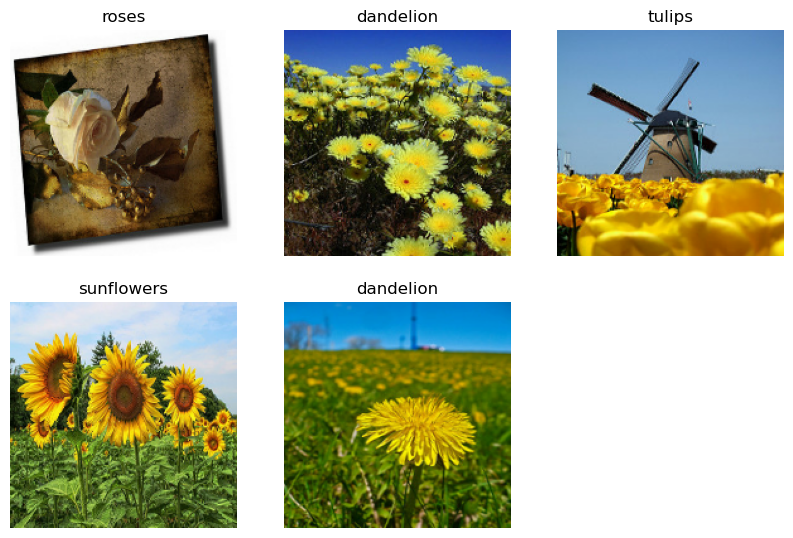

In [21]:
# Plot sample images from the dataset
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    for i in range(5):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()


In [25]:
# Optimize data loading
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)

# Normalize pixel values
normalization_layer = layers.Rescaling(1./255)
train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
val_dataset = val_dataset.map(lambda x, y: (normalization_layer(x), y))


In [27]:
model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(180, 180, 3)),
    layers.Conv2D(16, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names))
])

# Print model summary
model.summary()


A:\EDUCATIONAL\Data Science\Anaconda\Lib\site-packages\keras\src\layers\preprocessing\tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 178, 178, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,276,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,301,157 (12.59 MB)

 Trainable params: 3,301,157 (12.59 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)


In [31]:
# Train the model
epochs = 10
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epochs
)


Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 35s 259ms/step - accuracy: 0.2221 - loss: 1.6068 - val_accuracy: 0.2398 - val_loss: 1.6021
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 209ms/step - accuracy: 0.2448 - loss: 1.6017 - val_accuracy: 0.2398 - val_loss: 1.6025
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 198ms/step - accuracy: 0.2440 - loss: 1.6041 - val_accuracy: 0.2398 - val_loss: 1.6027
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 203ms/step - accuracy: 0.2498 - loss: 1.6021 - val_accuracy: 0.2398 - val_loss: 1.6023
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 201ms/step - accuracy: 0.2366 - loss: 1.6034 - val_accuracy: 0.2398 - val_loss: 1.6035
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 203ms/step - accuracy: 0.2592 - loss: 1.5959 - val_accuracy: 0.2398 - val_loss: 1.6019
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 199ms/step - accuracy: 0.2520 - loss: 1.5987 - val_accuracy: 0.2398 - val_loss: 1.6016
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 200ms/step - accuracy: 0.2278 - loss: 1.6052 - val_accu

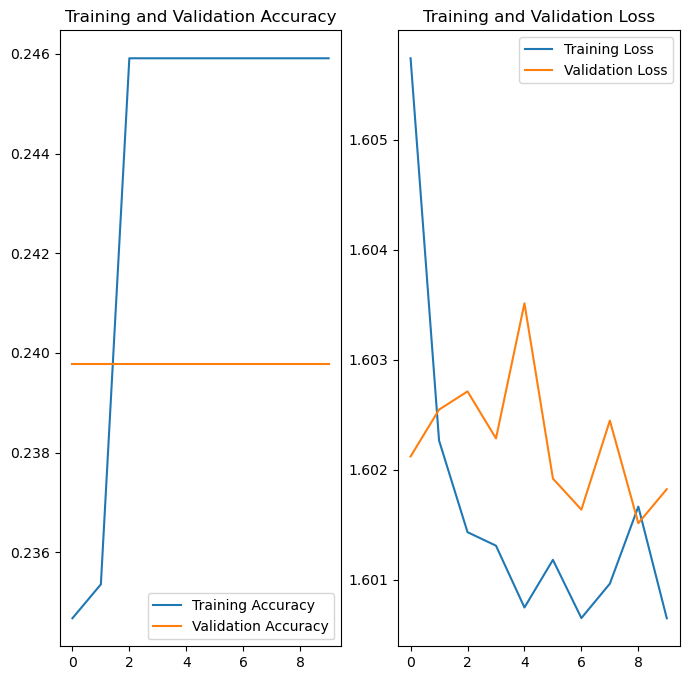

In [33]:
# Plot training and validation accuracy over epochs
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()


In [55]:
# Extract accuracy and loss data
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Get the number of epochs
epochs = len(acc)

# Print Training and Validation Accuracy and Loss for each epoch
print("Epoch | Training Accuracy | Validation Accuracy | Training Loss | Validation Loss")
print("-" * 75)

for epoch in range(epochs):
    print(f"{epoch+1:5d} | {acc[epoch]:18.4f} | {val_acc[epoch]:19.4f} | {loss[epoch]:13.4f} | {val_loss[epoch]:16.4f}")


Epoch | Training Accuracy | Validation Accuracy | Training Loss | Validation Loss
---------------------------------------------------------------------------
    1 |             0.2347 |              0.2398 |        1.6057 |           1.6021
    2 |             0.2354 |              0.2398 |        1.6023 |           1.6025
    3 |             0.2459 |              0.2398 |        1.6014 |           1.6027
    4 |             0.2459 |              0.2398 |        1.6013 |           1.6023
    5 |             0.2459 |              0.2398 |        1.6007 |           1.6035
    6 |             0.2459 |              0.2398 |        1.6012 |           1.6019
    7 |             0.2459 |              0.2398 |        1.6007 |           1.6016
    8 |             0.2459 |              0.2398 |        1.6010 |           1.6024
    9 |             0.2459 |              0.2398 |        1.6017 |           1.6015
   10 |             0.2459 |              0.2398 |        1.6007 |           1.6018


In [53]:
# Test the model with a flower image
from tensorflow.keras.utils import load_img, img_to_array

# Load a sample image
flower_path = os.path.join(data_dir, "dandelion/61242541_a04395e6bc.jpg")
img = load_img(flower_path, target_size=image_size)
img_array = img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

# Make prediction
predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])
predicted_class = class_names[np.argmax(score)]

print(
    f"This image most likely belongs to {predicted_class} "
    f"with a {100 * np.max(score):.2f} percent confidence."
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
This image most likely belongs to dandelion with a 39.42 percent confidence.
